In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Making encoded patch d > 2, we do not loose any information and perplexity does not collapse. When latent vector is flat, codebook usage is lower but not harms reconstruction

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 240.19it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 64
beta = 0.5
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 200
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 2 # adjustable encoder width for extra compression


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
mse = MeanSquaredError()
mse = mse.to(device)

In [10]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [11]:
event_train = events_train[:SELECTED_EVENTS][0]

In [12]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [13]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [14]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [15]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        # z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim).contiguous()
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        # z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [16]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [17]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [18]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    """
    d: int - how many codebook indexes could an encoded patch have    
    encoder_features: int - how many features are in encoder convolution output 
    
    """
    def __init__(self, d: int, slope: np.float64, encoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layers = nn.Sequential(
            nn.Linear(in_features=encoder_features, out_features=d),
            nn.BatchNorm1d(d),
            nn.LeakyReLU(slope)
        )
        
    def forward(self, x: torch.tensor) -> None:
        x_output = self.layers(x)
        return x_output
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - dinamically add required feature count for decoder
    
    """
    d: int - how many indexes could an encoded patch have
    decoder_features: int - how many features could a decoder convolution network have
    """
    
    def __init__(self, d: int, slope: np.float64, latent_dim: int, decoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        self.layers = nn.Sequential(
            nn.Linear(in_features=d, out_features=decoder_features),
            nn.BatchNorm1d(decoder_features),
            nn.LeakyReLU(slope)
        )
        self.decoder_features = decoder_features
        
    def forward(self, x: torch.tensor) -> None:
        dec_out = self.layers(x)
        return dec_out
    

In [19]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(d=d, slope=slope)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(d=d, latent_dim=latent_dim, slope=slope)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        encoder_output = self.encoder(x)
        b, c, w, h = encoder_output.shape
        encoder_flatten = encoder_output.view(b * c * h, w)
        
        z = self.fc_encoder_input(encoder_flatten)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z)
        
        z_q = self.fc_decoder_input(z_q)
        decoder_input = z_q.view(b, c, h, w)
        
        output = self.decoder(decoder_input)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [20]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d,
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/200: 100%|██████████| 199/199 [00:00<00:00, 258.47it/s, Loss (BCE + VQ)=0.128]


Epoch [1/200] summary:Average Loss: VQ + BCE = 0.2960,  Average loss: BCE = 0.0774 MSE = 0.00981844259875279 avg_perplexity = 5.052886410574218
Average validation set BCE loss: 0.06332533434033394
Before compression (Training)
Shape: (13, 8, 8)


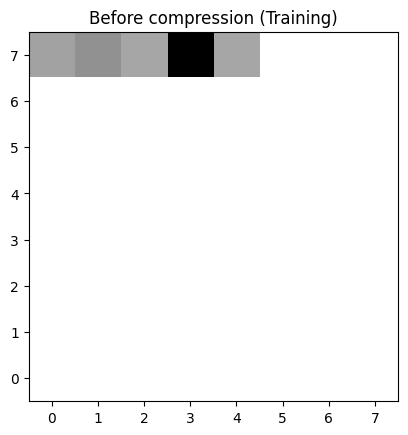

After compression (Training)
Shape: (1, 8, 8)


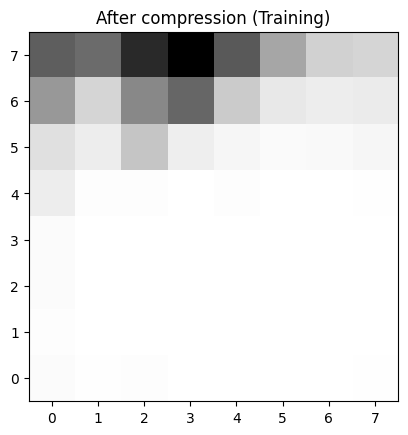

Epoch 2/200: 100%|██████████| 199/199 [00:00<00:00, 330.83it/s, Loss (BCE + VQ)=0.102] 


Epoch [2/200] summary:Average Loss: VQ + BCE = 0.1000,  Average loss: BCE = 0.0612 MSE = 0.006931880535791867 avg_perplexity = 5.0379040948110605
Average validation set BCE loss: 0.05906145870685577


Epoch 3/200: 100%|██████████| 199/199 [00:00<00:00, 329.33it/s, Loss (BCE + VQ)=0.0667]


Epoch [3/200] summary:Average Loss: VQ + BCE = 0.0755,  Average loss: BCE = 0.0572 MSE = 0.006397850493240596 avg_perplexity = 6.185250809444255
Average validation set BCE loss: 0.05666472688317299


Epoch 4/200: 100%|██████████| 199/199 [00:00<00:00, 314.47it/s, Loss (BCE + VQ)=0.063] 


...

Epoch [14/200] summary:Average Loss: VQ + BCE = 0.0531,  Average loss: BCE = 0.0455 MSE = 0.004508433910320752 avg_perplexity = 9.931298370936409
Average validation set BCE loss: 0.045562843978405


Epoch 15/200: 100%|██████████| 199/199 [00:00<00:00, 320.14it/s, Loss (BCE + VQ)=0.0704]


Epoch [15/200] summary:Average Loss: VQ + BCE = 0.0525,  Average loss: BCE = 0.0453 MSE = 0.004451363251530495 avg_perplexity = 9.95503007227452
Average validation set BCE loss: 0.04561371132731438


Epoch 16/200: 100%|██████████| 199/199 [00:00<00:00, 339.60it/s, Loss (BCE + VQ)=0.0535]


Epoch [16/200] summary:Average Loss: VQ + BCE = 0.0523,  Average loss: BCE = 0.0452 MSE = 0.004444748330533729 avg_perplexity = 9.947326377408588
Average validation set BCE loss: 0.04572843909263611
Before compression (Training)
Shape: (13, 8, 8)


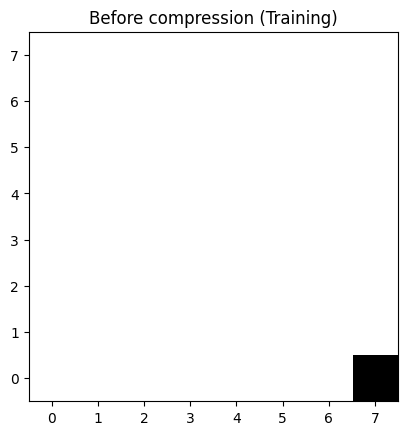

After compression (Training)
Shape: (1, 8, 8)


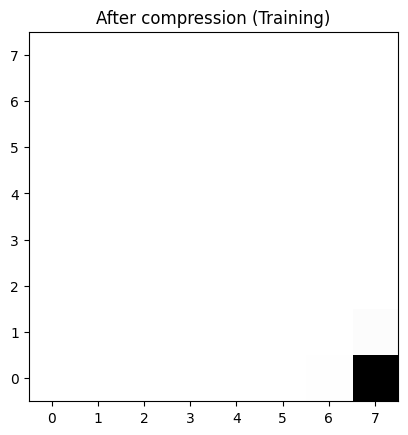

Epoch 17/200: 100%|██████████| 199/199 [00:00<00:00, 343.19it/s, Loss (BCE + VQ)=0.0416]


Epoch [17/200] summary:Average Loss: VQ + BCE = 0.0520,  Average loss: BCE = 0.0448 MSE = 0.004381035645281774 avg_perplexity = 10.001389853319331
Average validation set BCE loss: 0.04510200321674347


Epoch 18/200: 100%|██████████| 199/199 [00:00<00:00, 329.06it/s, Loss (BCE + VQ)=0.0523]


Epoch [18/200] summary:Average Loss: VQ + BCE = 0.0517,  Average loss: BCE = 0.0447 MSE = 0.004385514930124634 avg_perplexity = 10.074350256416666
Average validation set BCE loss: 0.04532926976680755


Epoch 19/200: 100%|██████████| 199/199 [00:00<00:00, 344.52it/s, Loss (BCE + VQ)=0.052] 


...

Epoch [29/200] summary:Average Loss: VQ + BCE = 0.0458,  Average loss: BCE = 0.0407 MSE = 0.0037303951910542484 avg_perplexity = 14.237448658775445
Average validation set BCE loss: 0.04282501637935639


Epoch 30/200: 100%|██████████| 199/199 [00:00<00:00, 343.51it/s, Loss (BCE + VQ)=0.0373]


Epoch [30/200] summary:Average Loss: VQ + BCE = 0.0455,  Average loss: BCE = 0.0404 MSE = 0.0036936483156385282 avg_perplexity = 14.371116719653259
Average validation set BCE loss: 0.042267259955406186


Epoch 31/200: 100%|██████████| 199/199 [00:00<00:00, 324.15it/s, Loss (BCE + VQ)=0.0415]


Epoch [31/200] summary:Average Loss: VQ + BCE = 0.0451,  Average loss: BCE = 0.0402 MSE = 0.0036413425348006453 avg_perplexity = 14.630835758381753
Average validation set BCE loss: 0.041876765340566634
Before compression (Training)
Shape: (13, 8, 8)


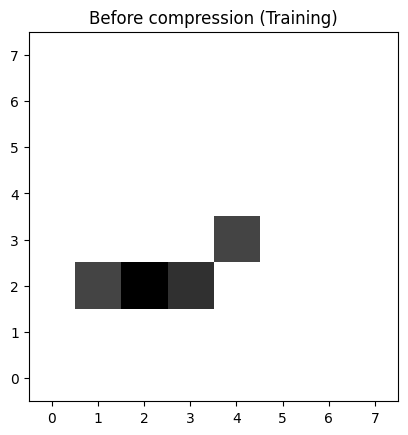

After compression (Training)
Shape: (1, 8, 8)


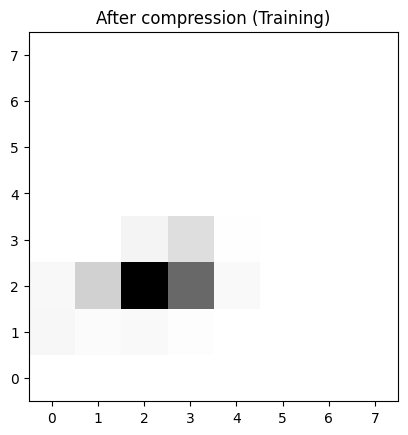

Epoch 32/200: 100%|██████████| 199/199 [00:00<00:00, 320.68it/s, Loss (BCE + VQ)=0.0359]


Epoch [32/200] summary:Average Loss: VQ + BCE = 0.0445,  Average loss: BCE = 0.0397 MSE = 0.003554312936989731 avg_perplexity = 14.754515609549518
Average validation set BCE loss: 0.04203639030456543


Epoch 33/200: 100%|██████████| 199/199 [00:00<00:00, 330.54it/s, Loss (BCE + VQ)=0.0344]


Epoch [33/200] summary:Average Loss: VQ + BCE = 0.0443,  Average loss: BCE = 0.0394 MSE = 0.0035077653931753347 avg_perplexity = 14.76595269016285
Average validation set BCE loss: 0.04065968990325928


Epoch 34/200: 100%|██████████| 199/199 [00:00<00:00, 334.87it/s, Loss (BCE + VQ)=0.0455]


...

Epoch [44/200] summary:Average Loss: VQ + BCE = 0.0410,  Average loss: BCE = 0.0368 MSE = 0.003048560558116279 avg_perplexity = 16.858030975763523
Average validation set BCE loss: 0.03938439637422562


Epoch 45/200: 100%|██████████| 199/199 [00:00<00:00, 345.02it/s, Loss (BCE + VQ)=0.0335]


Epoch [45/200] summary:Average Loss: VQ + BCE = 0.0409,  Average loss: BCE = 0.0368 MSE = 0.0030352491329672126 avg_perplexity = 17.09305627621598
Average validation set BCE loss: 0.03868042454123497


Epoch 46/200: 100%|██████████| 199/199 [00:00<00:00, 325.40it/s, Loss (BCE + VQ)=0.0414]


Epoch [46/200] summary:Average Loss: VQ + BCE = 0.0407,  Average loss: BCE = 0.0367 MSE = 0.003011031859044229 avg_perplexity = 17.427889220079585
Average validation set BCE loss: 0.039156032353639604
Before compression (Training)
Shape: (13, 8, 8)


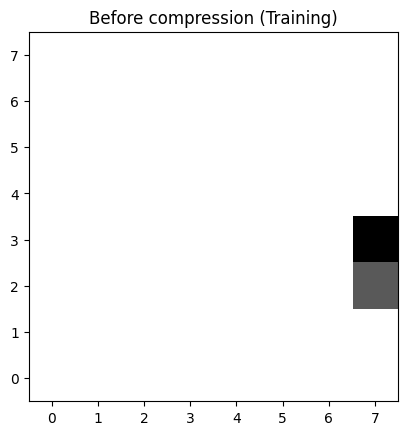

After compression (Training)
Shape: (1, 8, 8)


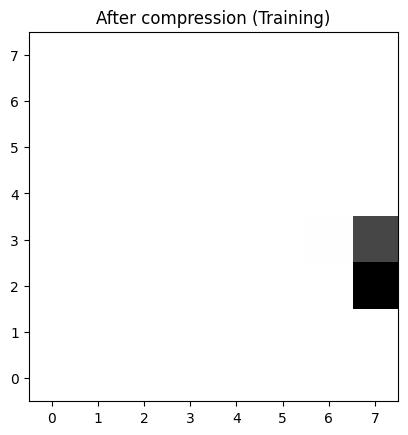

Epoch 47/200: 100%|██████████| 199/199 [00:00<00:00, 326.38it/s, Loss (BCE + VQ)=0.0317]


Epoch [47/200] summary:Average Loss: VQ + BCE = 0.0403,  Average loss: BCE = 0.0363 MSE = 0.0029455891596246978 avg_perplexity = 17.58090285679803
Average validation set BCE loss: 0.03996280655264854


Epoch 48/200: 100%|██████████| 199/199 [00:00<00:00, 325.13it/s, Loss (BCE + VQ)=0.0426]


Epoch [48/200] summary:Average Loss: VQ + BCE = 0.0402,  Average loss: BCE = 0.0363 MSE = 0.002925977217918028 avg_perplexity = 17.740607127472384
Average validation set BCE loss: 0.039535391330719


Epoch 49/200: 100%|██████████| 199/199 [00:00<00:00, 324.03it/s, Loss (BCE + VQ)=0.0331]


...

Epoch [59/200] summary:Average Loss: VQ + BCE = 0.0379,  Average loss: BCE = 0.0347 MSE = 0.0026157557608643967 avg_perplexity = 20.834575308028178
Average validation set BCE loss: 0.03847155645489693


Epoch 60/200: 100%|██████████| 199/199 [00:00<00:00, 330.96it/s, Loss (BCE + VQ)=0.0265]


Epoch [60/200] summary:Average Loss: VQ + BCE = 0.0375,  Average loss: BCE = 0.0344 MSE = 0.002547070529690976 avg_perplexity = 21.050118810567426
Average validation set BCE loss: 0.03892097920179367


Epoch 61/200: 100%|██████████| 199/199 [00:00<00:00, 332.52it/s, Loss (BCE + VQ)=0.0481]


Epoch [61/200] summary:Average Loss: VQ + BCE = 0.0374,  Average loss: BCE = 0.0343 MSE = 0.0025170159136558225 avg_perplexity = 21.805501017738226
Average validation set BCE loss: 0.037786907702684405
Before compression (Training)
Shape: (13, 8, 8)


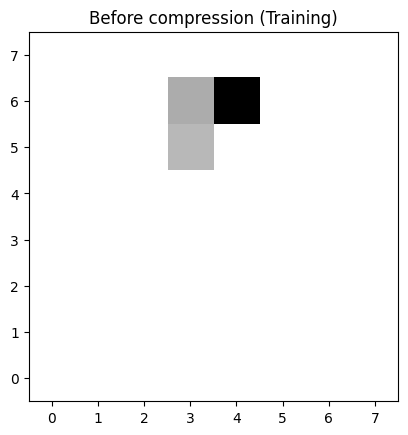

After compression (Training)
Shape: (1, 8, 8)


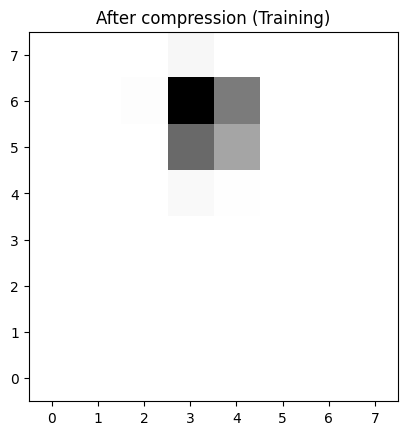

Epoch 62/200: 100%|██████████| 199/199 [00:00<00:00, 344.26it/s, Loss (BCE + VQ)=0.0309]


Epoch [62/200] summary:Average Loss: VQ + BCE = 0.0372,  Average loss: BCE = 0.0342 MSE = 0.002507058009107471 avg_perplexity = 22.08824032634946
Average validation set BCE loss: 0.03827853500843048


Epoch 63/200: 100%|██████████| 199/199 [00:00<00:00, 344.50it/s, Loss (BCE + VQ)=0.0201]


Epoch [63/200] summary:Average Loss: VQ + BCE = 0.0371,  Average loss: BCE = 0.0341 MSE = 0.0024842026534644727 avg_perplexity = 22.417039890385155
Average validation set BCE loss: 0.03780309408903122


Epoch 64/200: 100%|██████████| 199/199 [00:00<00:00, 343.51it/s, Loss (BCE + VQ)=0.0422]


...

Epoch [74/200] summary:Average Loss: VQ + BCE = 0.0357,  Average loss: BCE = 0.0330 MSE = 0.0022355210651461054 avg_perplexity = 24.013695031554256
Average validation set BCE loss: 0.03733065128326416


Epoch 75/200: 100%|██████████| 199/199 [00:00<00:00, 318.86it/s, Loss (BCE + VQ)=0.0192]


Epoch [75/200] summary:Average Loss: VQ + BCE = 0.0356,  Average loss: BCE = 0.0330 MSE = 0.0022447045512810986 avg_perplexity = 24.1554254598953
Average validation set BCE loss: 0.037439730018377304


Epoch 76/200: 100%|██████████| 199/199 [00:00<00:00, 342.05it/s, Loss (BCE + VQ)=0.03]  


Epoch [76/200] summary:Average Loss: VQ + BCE = 0.0354,  Average loss: BCE = 0.0328 MSE = 0.0021901769404435276 avg_perplexity = 24.3116681084561
Average validation set BCE loss: 0.037059060484170916
Before compression (Training)
Shape: (13, 8, 8)


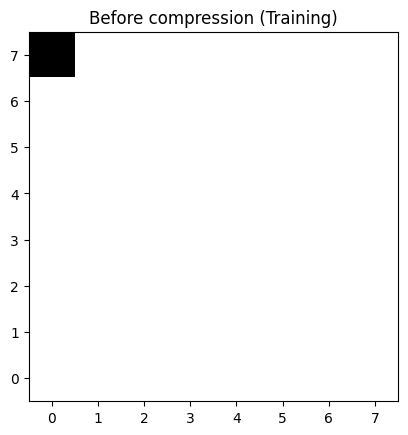

After compression (Training)
Shape: (1, 8, 8)


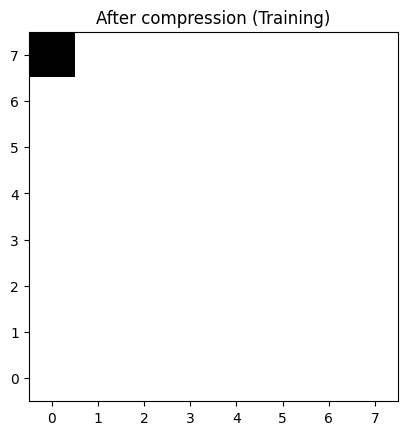

Epoch 77/200: 100%|██████████| 199/199 [00:00<00:00, 334.20it/s, Loss (BCE + VQ)=0.038] 


Epoch [77/200] summary:Average Loss: VQ + BCE = 0.0353,  Average loss: BCE = 0.0328 MSE = 0.0021804125567701596 avg_perplexity = 24.690559588485026
Average validation set BCE loss: 0.03784496933221817


Epoch 78/200: 100%|██████████| 199/199 [00:00<00:00, 334.95it/s, Loss (BCE + VQ)=0.0318]


Epoch [78/200] summary:Average Loss: VQ + BCE = 0.0352,  Average loss: BCE = 0.0326 MSE = 0.00215080574952796 avg_perplexity = 24.845148958752503
Average validation set BCE loss: 0.036521250009536745


Epoch 79/200: 100%|██████████| 199/199 [00:00<00:00, 340.27it/s, Loss (BCE + VQ)=0.0339]


...

Epoch [89/200] summary:Average Loss: VQ + BCE = 0.0344,  Average loss: BCE = 0.0320 MSE = 0.002011371977117156 avg_perplexity = 25.543157529591316
Average validation set BCE loss: 0.03670821413397789


Epoch 90/200: 100%|██████████| 199/199 [00:00<00:00, 341.42it/s, Loss (BCE + VQ)=0.0331]


Epoch [90/200] summary:Average Loss: VQ + BCE = 0.0344,  Average loss: BCE = 0.0321 MSE = 0.002008936058463126 avg_perplexity = 25.5598633157548
Average validation set BCE loss: 0.03606194108724594


Epoch 91/200: 100%|██████████| 199/199 [00:00<00:00, 344.74it/s, Loss (BCE + VQ)=0.0323]


Epoch [91/200] summary:Average Loss: VQ + BCE = 0.0341,  Average loss: BCE = 0.0318 MSE = 0.0019330810591690803 avg_perplexity = 25.755947755209764
Average validation set BCE loss: 0.035843832045793535
Before compression (Training)
Shape: (13, 8, 8)


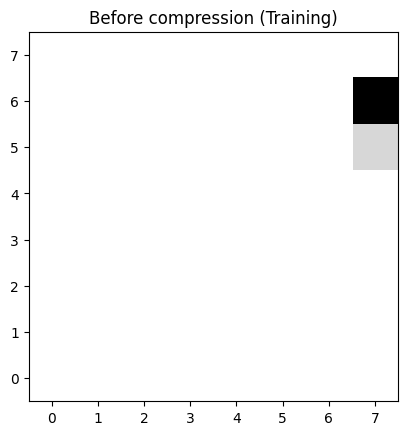

After compression (Training)
Shape: (1, 8, 8)


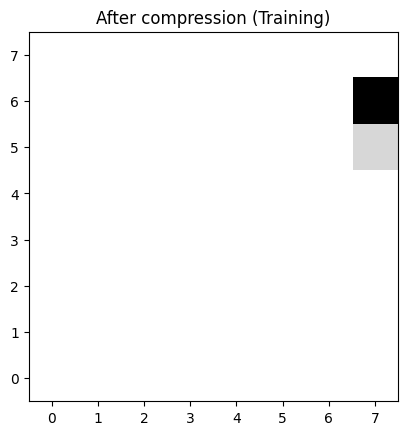

Epoch 92/200: 100%|██████████| 199/199 [00:00<00:00, 332.48it/s, Loss (BCE + VQ)=0.0274]


Epoch [92/200] summary:Average Loss: VQ + BCE = 0.0342,  Average loss: BCE = 0.0319 MSE = 0.0019707504499600686 avg_perplexity = 25.90162453579543
Average validation set BCE loss: 0.036416301131248476


Epoch 93/200: 100%|██████████| 199/199 [00:00<00:00, 352.12it/s, Loss (BCE + VQ)=0.0337]


Epoch [93/200] summary:Average Loss: VQ + BCE = 0.0342,  Average loss: BCE = 0.0319 MSE = 0.0019681656203143784 avg_perplexity = 26.068938518888388
Average validation set BCE loss: 0.036161462962627414


Epoch 94/200: 100%|██████████| 199/199 [00:00<00:00, 329.94it/s, Loss (BCE + VQ)=0.0259]


...

Epoch [104/200] summary:Average Loss: VQ + BCE = 0.0333,  Average loss: BCE = 0.0312 MSE = 0.0017819016377427545 avg_perplexity = 27.729266545281337
Average validation set BCE loss: 0.03636621013283729


Epoch 105/200: 100%|██████████| 199/199 [00:00<00:00, 328.07it/s, Loss (BCE + VQ)=0.0386]


Epoch [105/200] summary:Average Loss: VQ + BCE = 0.0333,  Average loss: BCE = 0.0312 MSE = 0.001779400707859003 avg_perplexity = 27.774517711083494
Average validation set BCE loss: 0.0364249050617218


Epoch 106/200: 100%|██████████| 199/199 [00:00<00:00, 320.80it/s, Loss (BCE + VQ)=0.0334]


Epoch [106/200] summary:Average Loss: VQ + BCE = 0.0332,  Average loss: BCE = 0.0311 MSE = 0.001738800640608741 avg_perplexity = 27.918049817109228
Average validation set BCE loss: 0.03662870302796364
Before compression (Training)
Shape: (13, 8, 8)


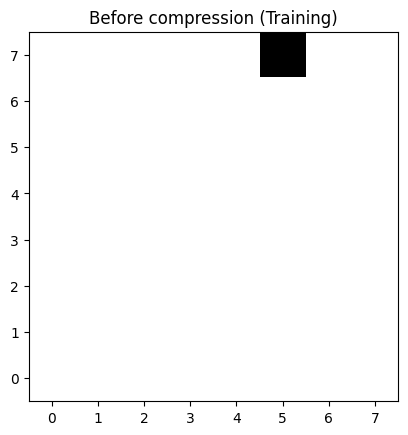

After compression (Training)
Shape: (1, 8, 8)


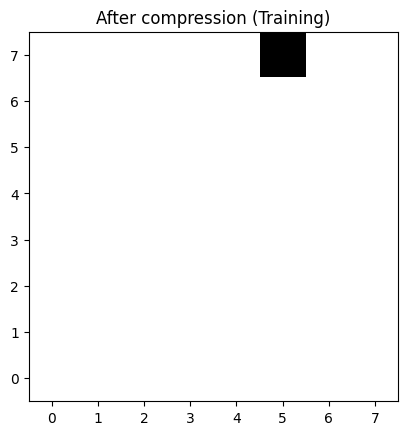

Epoch 107/200: 100%|██████████| 199/199 [00:00<00:00, 326.50it/s, Loss (BCE + VQ)=0.0497]


Epoch [107/200] summary:Average Loss: VQ + BCE = 0.0331,  Average loss: BCE = 0.0311 MSE = 0.001725065404895562 avg_perplexity = 27.88135003324729
Average validation set BCE loss: 0.0365570418536663


Epoch 108/200: 100%|██████████| 199/199 [00:00<00:00, 330.60it/s, Loss (BCE + VQ)=0.036] 


Epoch [108/200] summary:Average Loss: VQ + BCE = 0.0329,  Average loss: BCE = 0.0309 MSE = 0.001686150800722216 avg_perplexity = 28.074156305897777
Average validation set BCE loss: 0.03615842945873737


Epoch 109/200: 100%|██████████| 199/199 [00:00<00:00, 318.92it/s, Loss (BCE + VQ)=0.0328]


...

Epoch [119/200] summary:Average Loss: VQ + BCE = 0.0326,  Average loss: BCE = 0.0307 MSE = 0.0016348895853170048 avg_perplexity = 29.421183236280278
Average validation set BCE loss: 0.03674855679273605


Epoch 120/200: 100%|██████████| 199/199 [00:00<00:00, 350.19it/s, Loss (BCE + VQ)=0.0384]


Epoch [120/200] summary:Average Loss: VQ + BCE = 0.0324,  Average loss: BCE = 0.0305 MSE = 0.001600326400135536 avg_perplexity = 29.401087267314967
Average validation set BCE loss: 0.03690379709005356


Epoch 121/200: 100%|██████████| 199/199 [00:00<00:00, 338.12it/s, Loss (BCE + VQ)=0.0333]


Epoch [121/200] summary:Average Loss: VQ + BCE = 0.0323,  Average loss: BCE = 0.0305 MSE = 0.0015877754618788147 avg_perplexity = 29.608502364038824
Average validation set BCE loss: 0.037003413587808606
Before compression (Training)
Shape: (13, 8, 8)


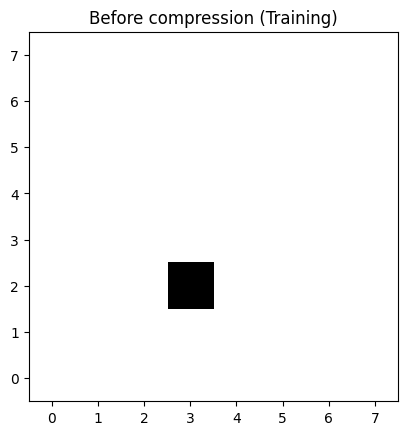

After compression (Training)
Shape: (1, 8, 8)


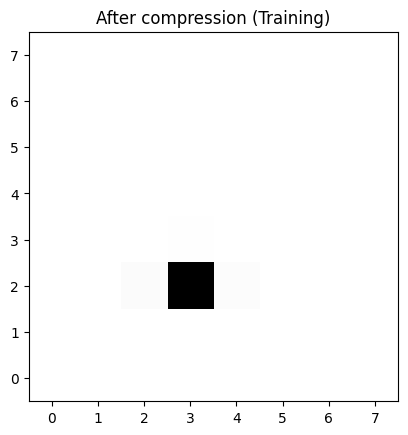

Epoch 122/200: 100%|██████████| 199/199 [00:00<00:00, 336.86it/s, Loss (BCE + VQ)=0.0389]


Epoch [122/200] summary:Average Loss: VQ + BCE = 0.0324,  Average loss: BCE = 0.0305 MSE = 0.0015964807150417462 avg_perplexity = 29.951253028371227
Average validation set BCE loss: 0.035756200551986694


Epoch 123/200: 100%|██████████| 199/199 [00:00<00:00, 355.26it/s, Loss (BCE + VQ)=0.0408]


Epoch [123/200] summary:Average Loss: VQ + BCE = 0.0323,  Average loss: BCE = 0.0305 MSE = 0.001581537059915425 avg_perplexity = 30.216733453261792
Average validation set BCE loss: 0.036168346926569936


Epoch 124/200: 100%|██████████| 199/199 [00:00<00:00, 352.70it/s, Loss (BCE + VQ)=0.0386]


...

Epoch [134/200] summary:Average Loss: VQ + BCE = 0.0315,  Average loss: BCE = 0.0298 MSE = 0.00140302513501415 avg_perplexity = 32.362566109278696
Average validation set BCE loss: 0.03584333509206772


Epoch 135/200: 100%|██████████| 199/199 [00:00<00:00, 347.74it/s, Loss (BCE + VQ)=0.0364]


Epoch [135/200] summary:Average Loss: VQ + BCE = 0.0315,  Average loss: BCE = 0.0299 MSE = 0.0014072173601484403 avg_perplexity = 32.36169565862148
Average validation set BCE loss: 0.03678586408495903


Epoch 136/200: 100%|██████████| 199/199 [00:00<00:00, 349.49it/s, Loss (BCE + VQ)=0.0242]


Epoch [136/200] summary:Average Loss: VQ + BCE = 0.0315,  Average loss: BCE = 0.0299 MSE = 0.0014207979287465464 avg_perplexity = 32.46636970558358
Average validation set BCE loss: 0.03657487742602825
Before compression (Training)
Shape: (13, 8, 8)


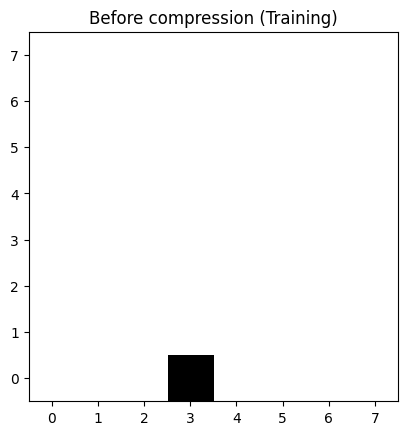

After compression (Training)
Shape: (1, 8, 8)


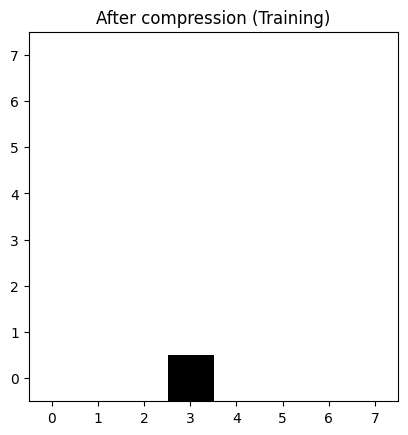

Epoch 137/200: 100%|██████████| 199/199 [00:00<00:00, 327.73it/s, Loss (BCE + VQ)=0.0228]


Epoch [137/200] summary:Average Loss: VQ + BCE = 0.0314,  Average loss: BCE = 0.0297 MSE = 0.0013890988597103475 avg_perplexity = 32.464302647652936
Average validation set BCE loss: 0.03600108213722706


Epoch 138/200: 100%|██████████| 199/199 [00:00<00:00, 335.12it/s, Loss (BCE + VQ)=0.044] 


Epoch [138/200] summary:Average Loss: VQ + BCE = 0.0315,  Average loss: BCE = 0.0298 MSE = 0.0014125446133179842 avg_perplexity = 32.67078844386729
Average validation set BCE loss: 0.03653813749551773


Epoch 139/200: 100%|██████████| 199/199 [00:00<00:00, 348.76it/s, Loss (BCE + VQ)=0.0383]


...

Epoch [149/200] summary:Average Loss: VQ + BCE = 0.0311,  Average loss: BCE = 0.0295 MSE = 0.0013108010937333406 avg_perplexity = 32.8997274619251
Average validation set BCE loss: 0.0364782527089119


Epoch 150/200: 100%|██████████| 199/199 [00:00<00:00, 328.89it/s, Loss (BCE + VQ)=0.0276]


Epoch [150/200] summary:Average Loss: VQ + BCE = 0.0312,  Average loss: BCE = 0.0296 MSE = 0.0013303288563397998 avg_perplexity = 32.97112069058059
Average validation set BCE loss: 0.036677802354097365


Epoch 151/200: 100%|██████████| 199/199 [00:00<00:00, 315.24it/s, Loss (BCE + VQ)=0.0293]


Epoch [151/200] summary:Average Loss: VQ + BCE = 0.0310,  Average loss: BCE = 0.0295 MSE = 0.0013085465410831922 avg_perplexity = 33.13435512331862
Average validation set BCE loss: 0.03648046404123306
Before compression (Training)
Shape: (13, 8, 8)


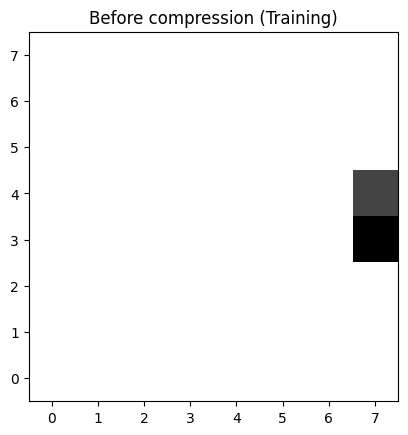

After compression (Training)
Shape: (1, 8, 8)


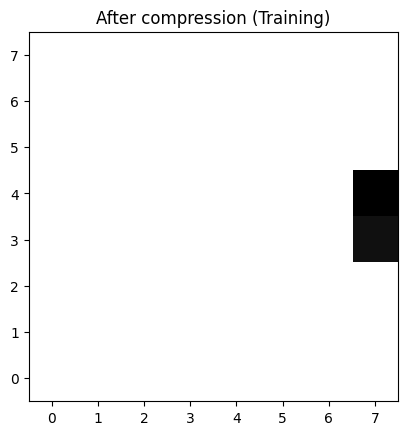

Epoch 152/200: 100%|██████████| 199/199 [00:00<00:00, 326.24it/s, Loss (BCE + VQ)=0.0411]


Epoch [152/200] summary:Average Loss: VQ + BCE = 0.0310,  Average loss: BCE = 0.0294 MSE = 0.0012733127846354477 avg_perplexity = 33.1013632443682
Average validation set BCE loss: 0.036932168528437614


Epoch 153/200: 100%|██████████| 199/199 [00:00<00:00, 343.39it/s, Loss (BCE + VQ)=0.0306]


Epoch [153/200] summary:Average Loss: VQ + BCE = 0.0311,  Average loss: BCE = 0.0295 MSE = 0.0013262574998521475 avg_perplexity = 33.154092961220286
Average validation set BCE loss: 0.036857648938894275


Epoch 154/200: 100%|██████████| 199/199 [00:00<00:00, 346.46it/s, Loss (BCE + VQ)=0.0219]


...

Epoch [164/200] summary:Average Loss: VQ + BCE = 0.0306,  Average loss: BCE = 0.0291 MSE = 0.0012023581891559326 avg_perplexity = 33.72234092405693
Average validation set BCE loss: 0.03734888546168804


Epoch 165/200: 100%|██████████| 199/199 [00:00<00:00, 345.28it/s, Loss (BCE + VQ)=0.0261]


Epoch [165/200] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0290 MSE = 0.0011747734774437606 avg_perplexity = 33.82436033469349
Average validation set BCE loss: 0.0365679994225502


Epoch 166/200: 100%|██████████| 199/199 [00:00<00:00, 340.13it/s, Loss (BCE + VQ)=0.0253]


Epoch [166/200] summary:Average Loss: VQ + BCE = 0.0304,  Average loss: BCE = 0.0290 MSE = 0.001173637689783907 avg_perplexity = 34.03176234834757
Average validation set BCE loss: 0.03737478479743004
Before compression (Training)
Shape: (13, 8, 8)


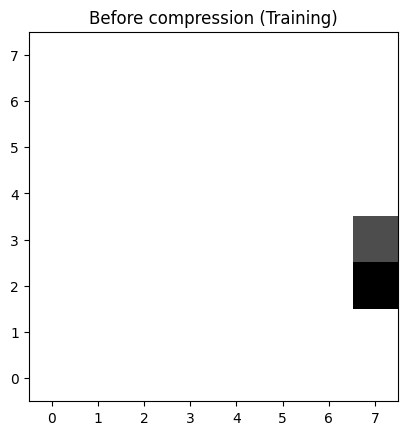

After compression (Training)
Shape: (1, 8, 8)


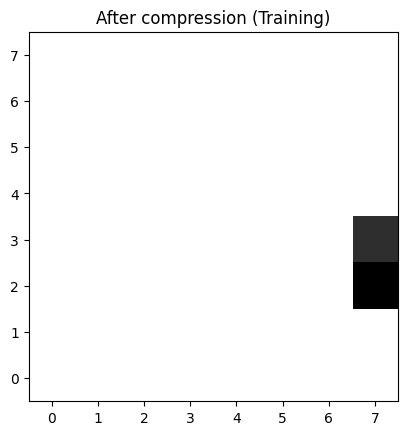

Epoch 167/200: 100%|██████████| 199/199 [00:00<00:00, 326.22it/s, Loss (BCE + VQ)=0.0249]


Epoch [167/200] summary:Average Loss: VQ + BCE = 0.0303,  Average loss: BCE = 0.0289 MSE = 0.0011557828791172772 avg_perplexity = 34.07741243755398
Average validation set BCE loss: 0.037300141900777815


Epoch 168/200: 100%|██████████| 199/199 [00:00<00:00, 339.30it/s, Loss (BCE + VQ)=0.0351]


Epoch [168/200] summary:Average Loss: VQ + BCE = 0.0305,  Average loss: BCE = 0.0290 MSE = 0.0011750645593309485 avg_perplexity = 34.00811469494997
Average validation set BCE loss: 0.03724377192556858


Epoch 169/200: 100%|██████████| 199/199 [00:00<00:00, 341.75it/s, Loss (BCE + VQ)=0.0374]


...

Epoch [179/200] summary:Average Loss: VQ + BCE = 0.0302,  Average loss: BCE = 0.0288 MSE = 0.0011260831136555977 avg_perplexity = 34.66033172607422
Average validation set BCE loss: 0.038009464740753174


Epoch 180/200: 100%|██████████| 199/199 [00:00<00:00, 329.39it/s, Loss (BCE + VQ)=0.0264]


Epoch [180/200] summary:Average Loss: VQ + BCE = 0.0301,  Average loss: BCE = 0.0287 MSE = 0.0011041728772653557 avg_perplexity = 34.64090056874644
Average validation set BCE loss: 0.036762085556983945


Epoch 181/200: 100%|██████████| 199/199 [00:00<00:00, 325.51it/s, Loss (BCE + VQ)=0.0354]


Epoch [181/200] summary:Average Loss: VQ + BCE = 0.0301,  Average loss: BCE = 0.0287 MSE = 0.001079018254373597 avg_perplexity = 34.58777088376146
Average validation set BCE loss: 0.03769498281180859
Before compression (Training)
Shape: (13, 8, 8)


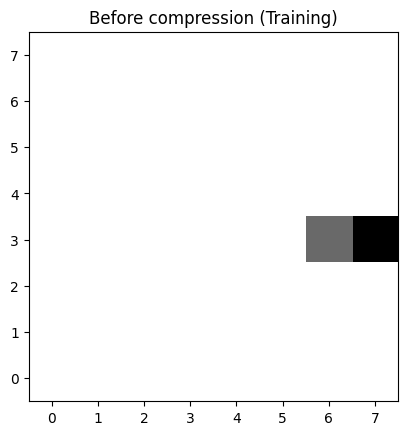

After compression (Training)
Shape: (1, 8, 8)


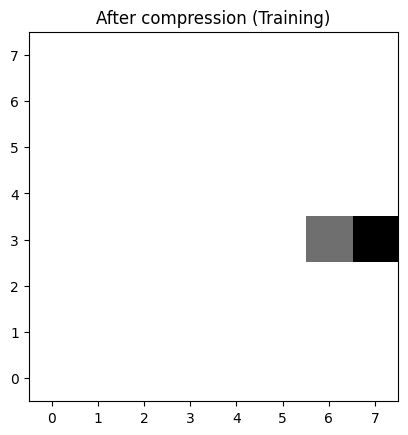

Epoch 182/200: 100%|██████████| 199/199 [00:00<00:00, 340.65it/s, Loss (BCE + VQ)=0.0229]


Epoch [182/200] summary:Average Loss: VQ + BCE = 0.0300,  Average loss: BCE = 0.0287 MSE = 0.0010822345254048891 avg_perplexity = 34.68727153030472
Average validation set BCE loss: 0.03796771690249443


Epoch 183/200: 100%|██████████| 199/199 [00:00<00:00, 339.20it/s, Loss (BCE + VQ)=0.0236]


Epoch [183/200] summary:Average Loss: VQ + BCE = 0.0301,  Average loss: BCE = 0.0287 MSE = 0.0011054733405404505 avg_perplexity = 34.7309249609559
Average validation set BCE loss: 0.03706730306148529


Epoch 184/200: 100%|██████████| 199/199 [00:00<00:00, 332.76it/s, Loss (BCE + VQ)=0.0336]


...

Epoch [194/200] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0285 MSE = 0.0010445323968996485 avg_perplexity = 35.05585676221991
Average validation set BCE loss: 0.037050620466470716


Epoch 195/200: 100%|██████████| 199/199 [00:00<00:00, 339.17it/s, Loss (BCE + VQ)=0.0316]


Epoch [195/200] summary:Average Loss: VQ + BCE = 0.0299,  Average loss: BCE = 0.0285 MSE = 0.0010488125315432123 avg_perplexity = 35.0572959765717
Average validation set BCE loss: 0.03763601034879684


Epoch 196/200: 100%|██████████| 199/199 [00:00<00:00, 329.88it/s, Loss (BCE + VQ)=0.024] 


Epoch [196/200] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0284 MSE = 0.001024488785278389 avg_perplexity = 35.13025895315199
Average validation set BCE loss: 0.03766847178339958
Before compression (Training)
Shape: (13, 8, 8)


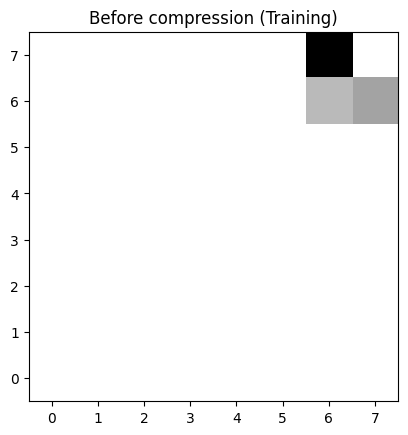

After compression (Training)
Shape: (1, 8, 8)


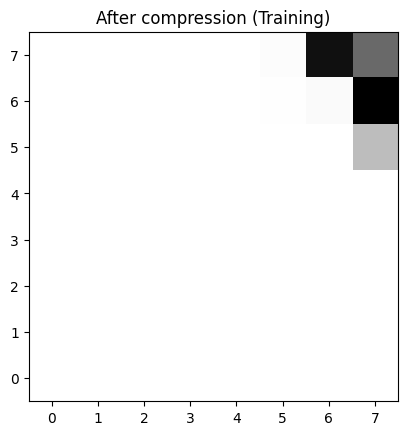

Epoch 197/200: 100%|██████████| 199/199 [00:00<00:00, 338.74it/s, Loss (BCE + VQ)=0.031] 


Epoch [197/200] summary:Average Loss: VQ + BCE = 0.0298,  Average loss: BCE = 0.0285 MSE = 0.001037190135055919 avg_perplexity = 35.02034548658821
Average validation set BCE loss: 0.037375759333372116


Epoch 198/200: 100%|██████████| 199/199 [00:00<00:00, 335.42it/s, Loss (BCE + VQ)=0.0258]


Epoch [198/200] summary:Average Loss: VQ + BCE = 0.0298,  Average loss: BCE = 0.0285 MSE = 0.0010388241059979865 avg_perplexity = 35.12306463538702
Average validation set BCE loss: 0.037163229286670686


Epoch 199/200: 100%|██████████| 199/199 [00:00<00:00, 335.24it/s, Loss (BCE + VQ)=0.0191]


Epoch [199/200] summary:Average Loss: VQ + BCE = 0.0298,  Average loss: BCE = 0.0285 MSE = 0.0010278685243353342 avg_perplexity = 35.1300461639711
Average validation set BCE loss: 0.037663692608475685


Epoch 200/200: 100%|██████████| 199/199 [00:00<00:00, 334.39it/s, Loss (BCE + VQ)=0.025] 


Epoch [200/200] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0284 MSE = 0.0010161644579660166 avg_perplexity = 35.07293289989682
Average validation set BCE loss: 0.037296777963638304
Before compression (Validation)
Shape: (64, 8, 8)


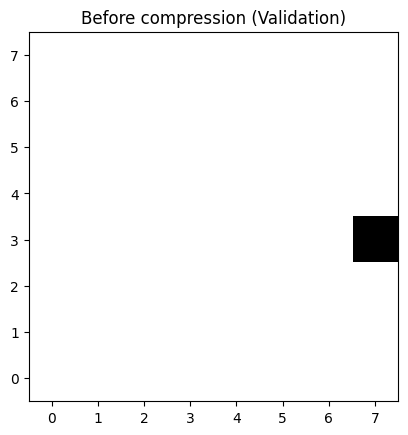

After compression (Validation)
Shape: (1, 8, 8)


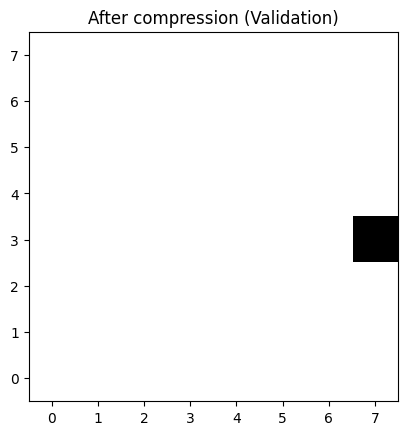

----------------------------------------
Patch = 0 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


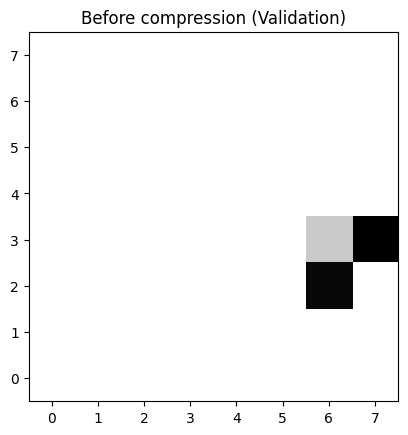

After compression (Validation)
Shape: (1, 8, 8)


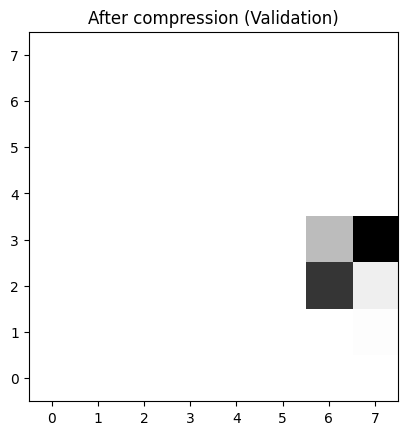

----------------------------------------
Patch = 1 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


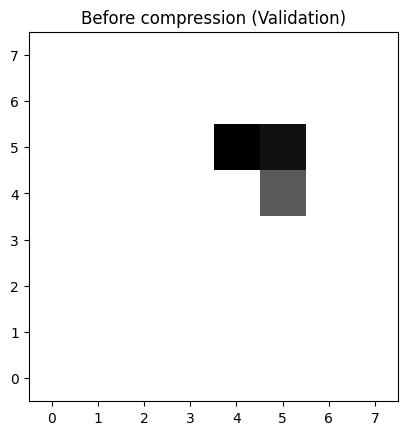

After compression (Validation)
Shape: (1, 8, 8)


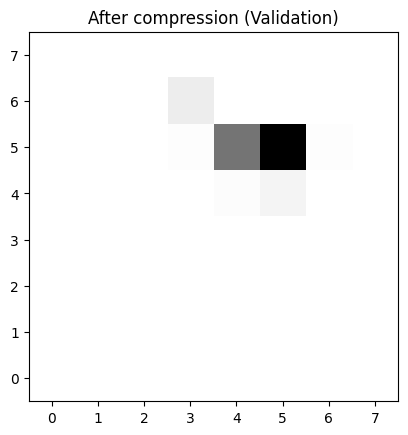

----------------------------------------
Patch = 2 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


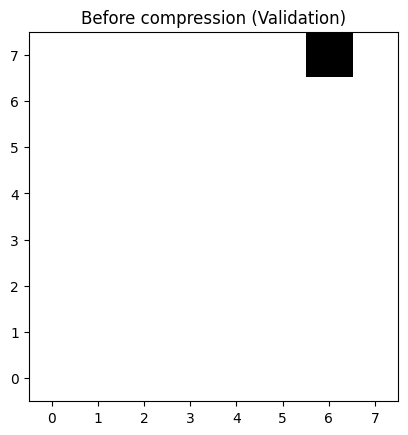

After compression (Validation)
Shape: (1, 8, 8)


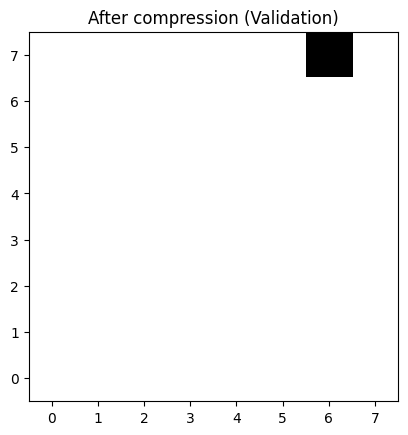

----------------------------------------
Patch = 3 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


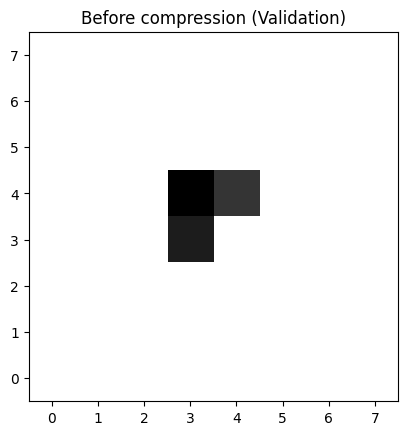

After compression (Validation)
Shape: (1, 8, 8)


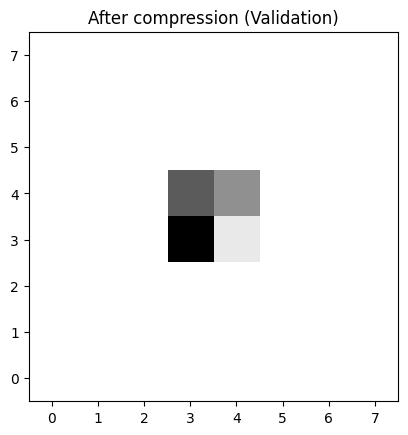

----------------------------------------
Patch = 4 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (3904) x (2)
Compression ratio = 2.8126963439443733
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 27.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [21]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val.shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------width_val------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
            
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(d, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        d,
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [22]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


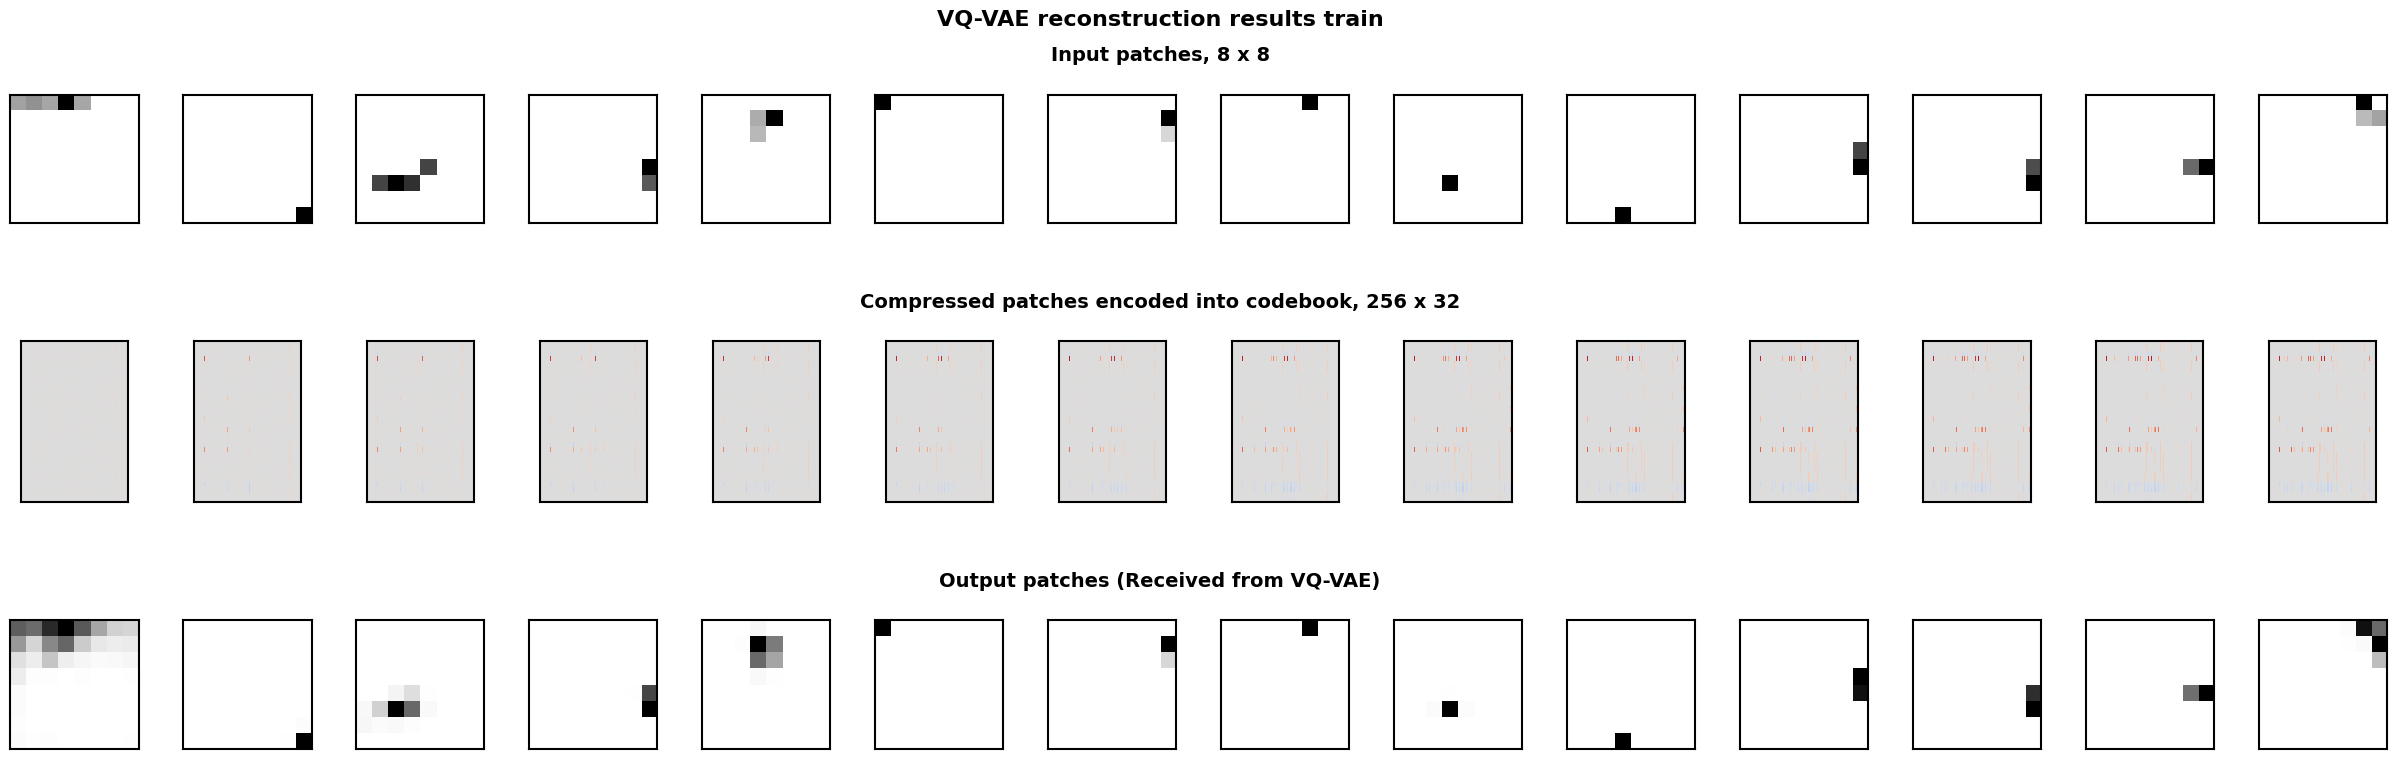

In [23]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

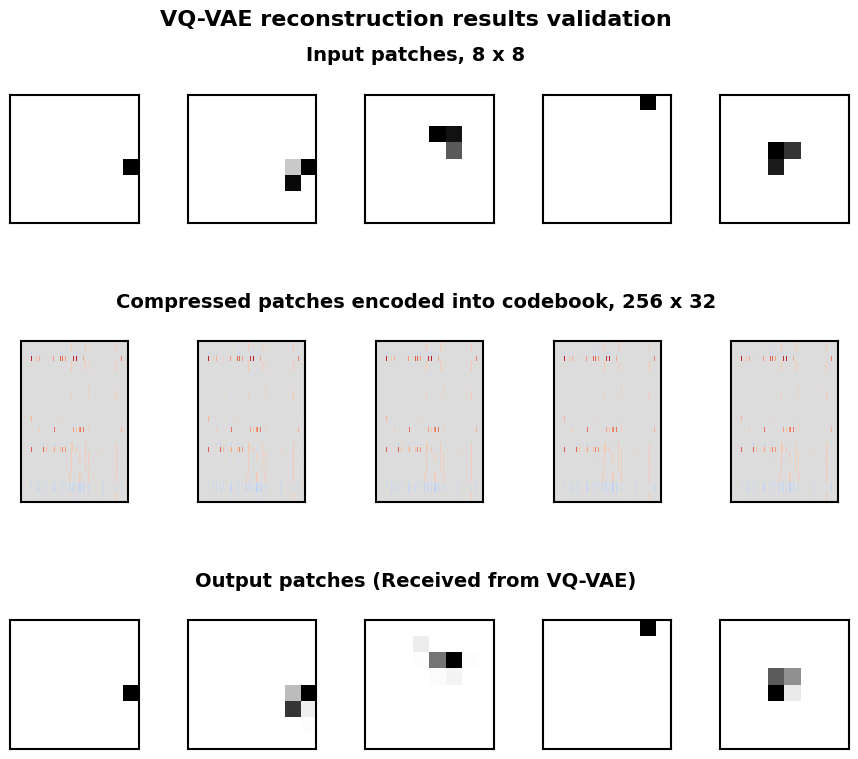

In [24]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [25]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.020515112206339836
encoder.1.weight 0.0017557772807776928
encoder.1.bias 0.002912017982453108
encoder.3.weight 0.029201924800872803
encoder.4.weight 0.001989316660910845
encoder.4.bias 0.002142946934327483
encoder.6.weight 0.035494960844516754
encoder.7.weight 0.004503644537180662
encoder.7.bias 0.0029326912481337786
encoder.8.stack.0.res_block.1.weight 0.013489940203726292
encoder.8.stack.0.res_block.3.weight 0.011255240999162197
encoder.8.stack.1.res_block.1.weight 0.01992933265864849
encoder.8.stack.1.res_block.3.weight 0.016776900738477707
fc_encoder_input.layers.0.weight 0.0048697697930037975
fc_encoder_input.layers.0.bias 7.73964892175627e-09
fc_encoder_input.layers.1.weight 0.012316080741584301
fc_encoder_input.layers.1.bias 0.015249407850205898
vq_layer.embedding.weight 0.0010958747006952763
fc_decoder_input.layers.0.weight 0.004771803505718708
fc_decoder_input.layers.0.bias 1.5875226466732784e-08
fc_decoder_input.layers.1.weight 0.001

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


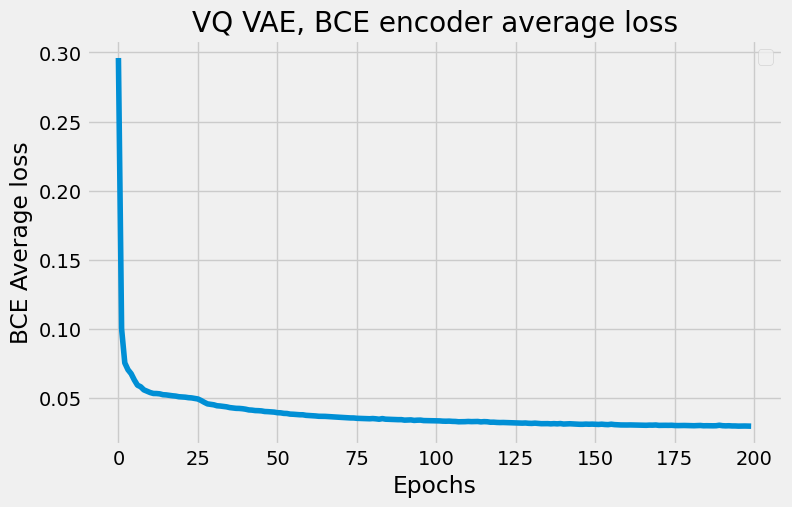

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [26]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [27]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("../bin/vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.29861
Based on test set (size = 45), average codebook perplexity = 35.59690/256
Saved VQ-VAE test results


In [28]:
len(patches_before_test)

6

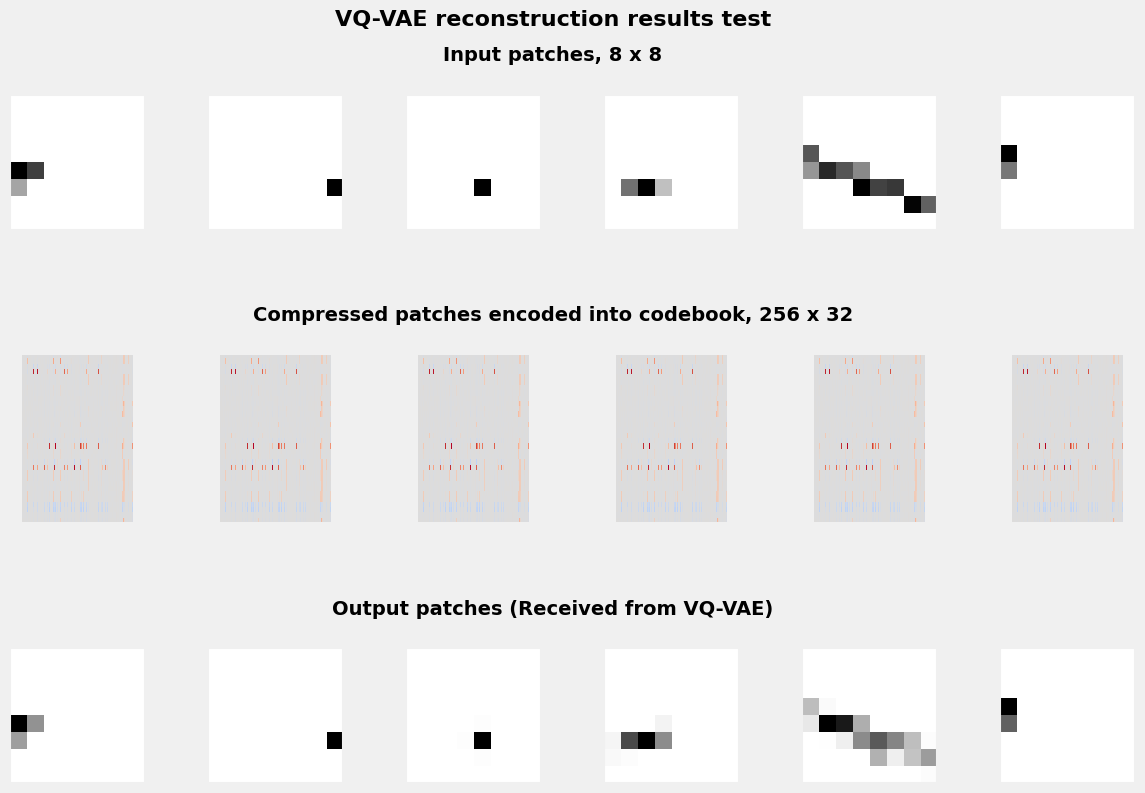

In [29]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

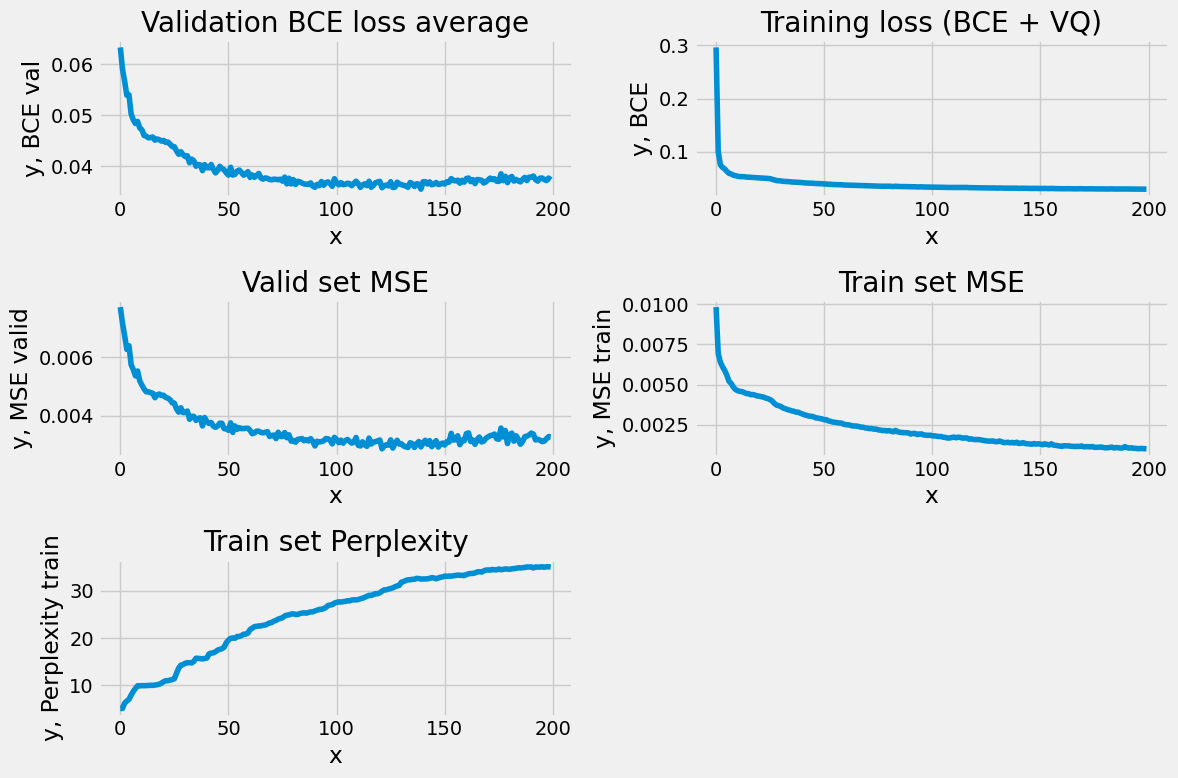

In [30]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)
